In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/basetables/suitability_index_basetable_percentiles.csv")
df

,Latitude,Longitude,Mean Correlation,min_distance_to_line_km,avg_capacity_factor,avg_solar_radiation,score_km,score_wind_correlation,score_wind_capacity,score_solar_radiation
0,-10.75,142.50,0.056396,597.4,0.550048,475.25894,3,44,100,55
1,-11.00,142.25,0.060105,589.0,0.329239,478.09567,3,41,58,52
2,-11.00,142.50,0.054841,574.1,0.372655,472.80290,3,45,75,57
3,-11.25,131.25,0.018067,126.9,0.161143,502.90063,51,85,12,25
4,-11.25,142.25,0.053391,566.6,0.243367,467.21436,4,47,25,61
...,...,...,...,...,...,...,...,...,...,...
11108,-43.25,146.75,0.118552,18.8,0.197530,286.96558,83,21,17,100
11109,-43.25,147.00,0.138379,10.3,0.247404,295.09700,90,19,26,100
11110,-43.50,146.25,0.090640,67.2,0.431569,285.83500,65,25,91,100
11111,-43.50,146.50,0.089652,51.9,0.374918,289.17334,70,26,76,100


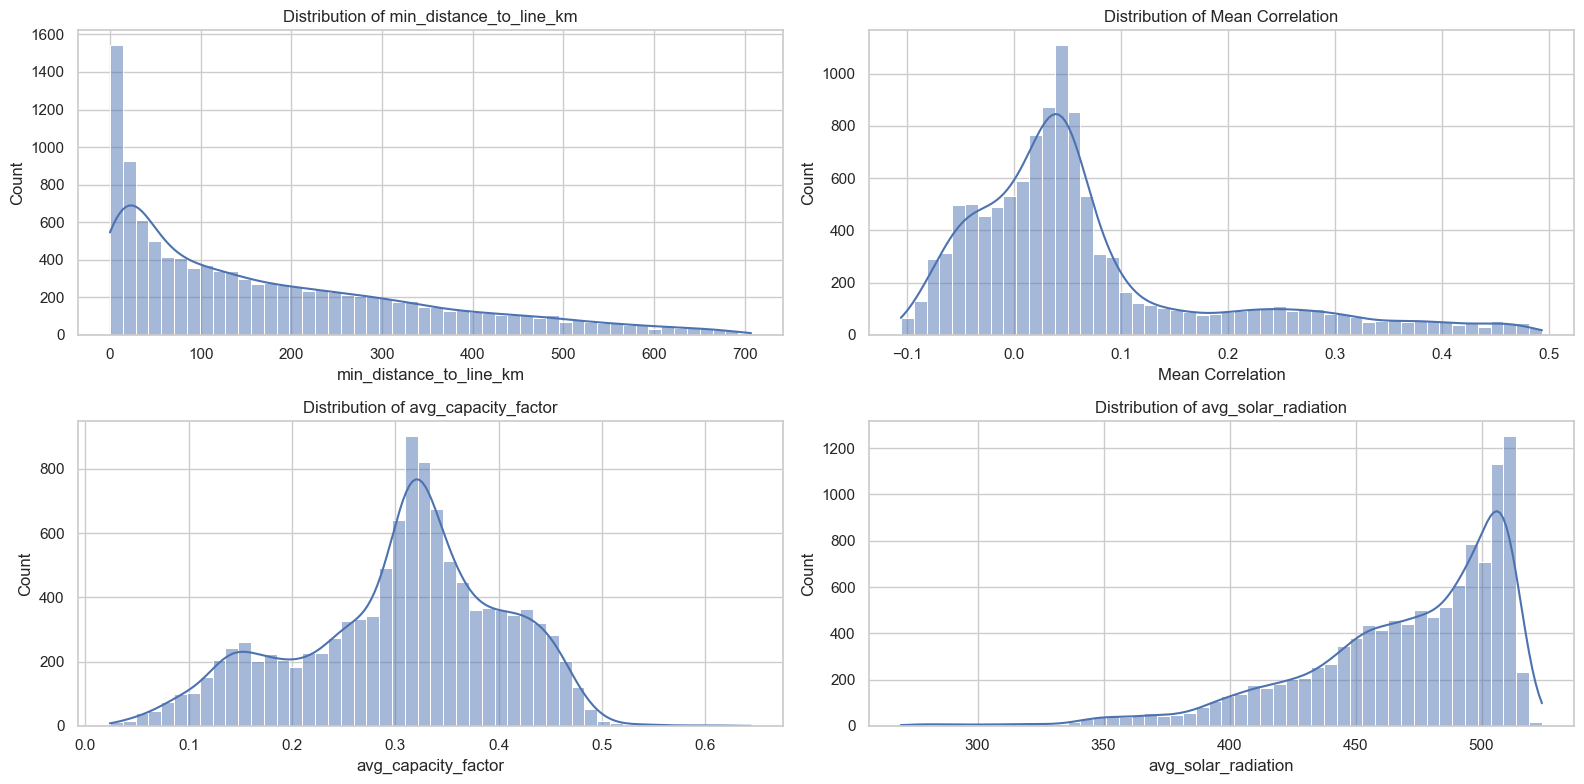

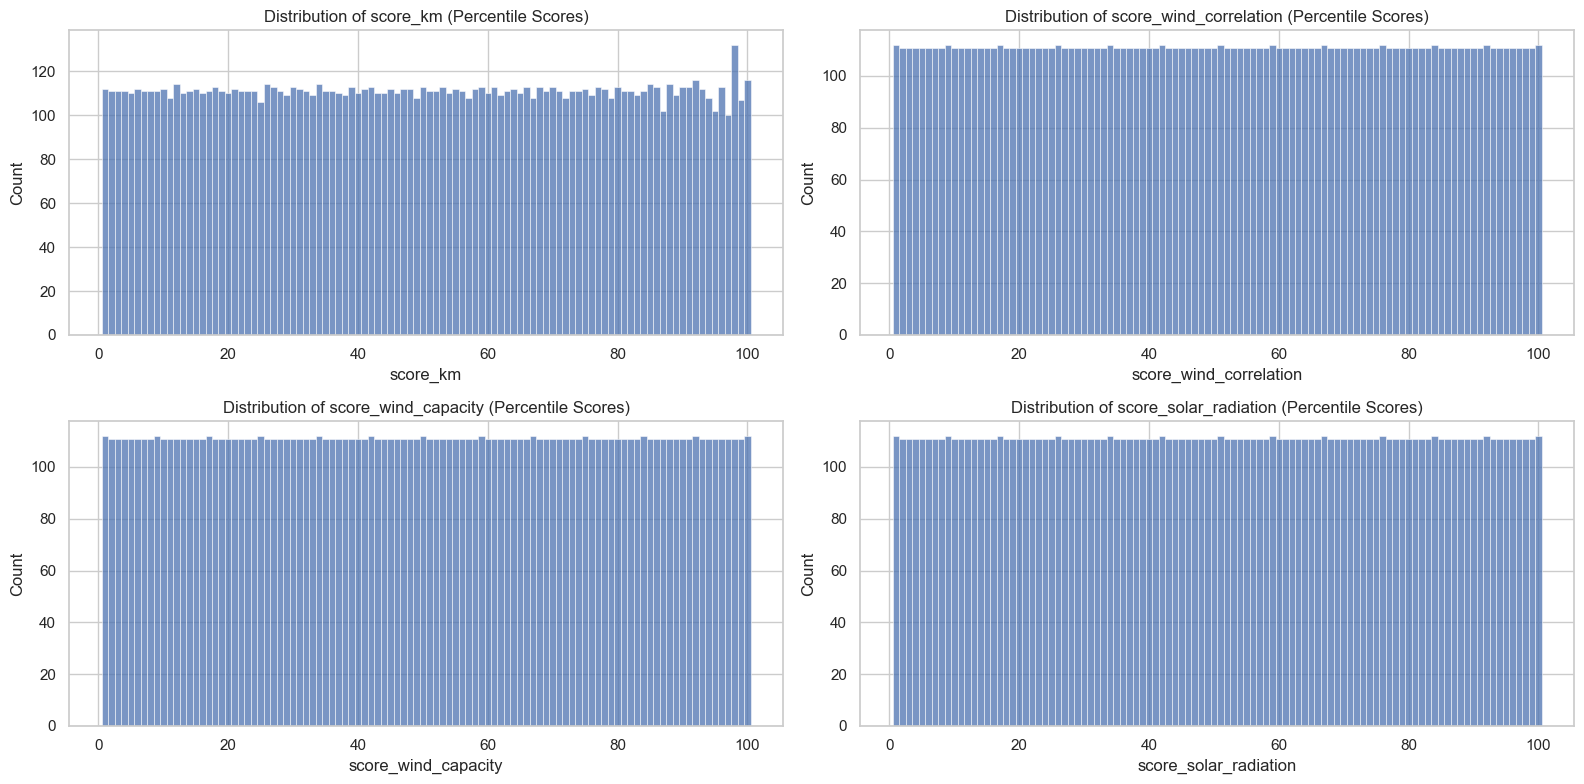

In [6]:
sns.set(style="whitegrid")

original_vars = [
    'min_distance_to_line_km', 
    'Mean Correlation', 
    'avg_capacity_factor', 
    'avg_solar_radiation'
]

score_vars = [
    'score_km', 
    'score_wind_correlation', 
    'score_wind_capacity', 
    'score_solar_radiation'
]

# raw distributions
plt.figure(figsize=(16, 8))
for idx, var in enumerate(original_vars, 1):
    plt.subplot(2, 2, idx)
    sns.histplot(df[var].abs() if 'corr' in var else df[var], bins=50, kde=True)
    plt.title(f"Distribution of {var}")
plt.tight_layout()
plt.show()

# percentiles
plt.figure(figsize=(16, 8))
for idx, var in enumerate(score_vars, 1):
    plt.subplot(2, 2, idx)
    sns.histplot(df[var], bins=100, discrete=True)
    plt.title(f"Distribution of {var} (Percentile Scores)")
plt.tight_layout()
plt.show()


In [8]:
columns_info = {
    'min_distance_to_line_km': {'abs': False, 'invert': True},
    'Mean Correlation': {'abs': True, 'invert': True},
    'avg_capacity_factor': {'abs': False, 'invert': False},
    'avg_solar_radiation': {'abs': False, 'invert': True},
}

def print_score_bins(series: pd.Series, invert: bool, feature_name: str, n_bins: int = 100):
    """
    Prints the bin edges and score labels for a given series based on quantiles.
    n_bins = 100 for percentiles, 10 for deciles, etc.
    """
    # compute quantile breakpoints
    breakpoints = series.quantile([i / n_bins for i in range(n_bins + 1)]).values
    breakpoints = pd.Series(breakpoints).drop_duplicates().values  # remove duplicate edges

    # generate labels depending on direction
    if invert:
        labels = list(range(n_bins, 0, -1))  # e.g., 100 to 1
    else:
        labels = list(range(1, n_bins + 1))  # e.g., 1 to 100

    print(f"\nScore bins for {feature_name}:")
    for i in range(min(len(labels), len(breakpoints) - 1)):
        low = breakpoints[i]
        high = breakpoints[i + 1]
        print(f"  Score {labels[i]:3}: [{low:.4f} -> {high:.4f}]")
    
    if len(breakpoints) <= len(labels):  # catch if fewer bins due to duplicates
        print(f"  Score {labels[len(breakpoints)-1]:3}: > {breakpoints[-1]:.4f}")

for var, options in columns_info.items():
    series = df[var]
    if options['abs']:
        series = series.abs()
    
    print_score_bins(series, options['invert'], var, n_bins=100)


Score bins for min_distance_to_line_km:
  Score 100: [0.0000 -> 0.6000]
  Score  99: [0.6000 -> 1.3240]
  Score  98: [1.3240 -> 2.1000]
  Score  97: [2.1000 -> 2.9000]
  Score  96: [2.9000 -> 3.8000]
  Score  95: [3.8000 -> 4.6000]
  Score  94: [4.6000 -> 5.5840]
  Score  93: [5.5840 -> 6.5000]
  Score  92: [6.5000 -> 7.7000]
  Score  91: [7.7000 -> 9.0000]
  Score  90: [9.0000 -> 10.4000]
  Score  89: [10.4000 -> 11.7000]
  Score  88: [11.7000 -> 13.1000]
  Score  87: [13.1000 -> 14.3000]
  Score  86: [14.3000 -> 15.7000]
  Score  85: [15.7000 -> 17.1000]
  Score  84: [17.1000 -> 18.7000]
  Score  83: [18.7000 -> 20.4000]
  Score  82: [20.4000 -> 22.1000]
  Score  81: [22.1000 -> 23.8000]
  Score  80: [23.8000 -> 25.7000]
  Score  79: [25.7000 -> 27.9000]
  Score  78: [27.9000 -> 29.8000]
  Score  77: [29.8000 -> 32.4000]
  Score  76: [32.4000 -> 35.1000]
  Score  75: [35.1000 -> 37.6000]
  Score  74: [37.6000 -> 40.4000]
  Score  73: [40.4000 -> 43.0000]
  Score  72: [43.0000 -> 46.